## Logistisk/sigmoid funksjon
Plott den logistiske funksjonen (s. 139 i ITSL). Hvorfor er denne funksjonen egnet til å predikere et binært kategorisk utfall?

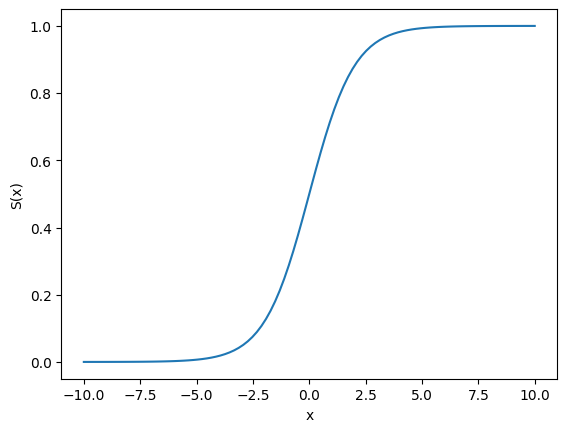

In [7]:
a = 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def logistisk(x, beta_0=0, beta_1=1):
    z = beta_0 + beta_1*x
    return np.exp(z) / (1 + np.exp(z))

x = np.linspace(-10, 10, 100)
y = logistisk(x)

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('S(x)')
plt.show()

## Parametrene $\beta_0$ og $\beta_1$
Uforsk hvordan parametrene $\beta_0$ og $\beta_1$ flytter på funksjonen.

In [1]:
from ipywidgets import interact, FloatSlider
import numpy as np
import matplotlib.pyplot as plt
def logistisk(x, beta_0=0, beta_1=1):
    z = beta_0 + beta_1 * x
    return np.exp(z) / (1 + np.exp(z))

def plot_logistisk(x_range, beta_0, beta_1):
    x = np.linspace(-(x_range), x_range, 100)
    y = logistisk(x, beta_0, beta_1)
    plt.plot(x, y)
    plt.xlabel('x')
    plt.ylabel('S(x)')
    plt.show()

interact(plot_logistisk, x_range=FloatSlider(value=10, min=0, max=20, step=0.1, description='x range'),
        beta_0=FloatSlider(value=0, min=-10, max=10, step=0.1, description='beta_0'),
        beta_1=FloatSlider(value=1, min=-10, max=10, step=0.1, description='beta_1'))

interactive(children=(FloatSlider(value=10.0, description='x range', max=20.0), FloatSlider(value=0.0, descrip…

<function __main__.plot_logistisk(x_range, beta_0, beta_1)>

## Datasett med kredittkortmislighold
Last inn `default`-datasettet (zenodo.org/record/6199560/files/default.csv). Plott mislighold mot hvor mye kredittkortlån en person har (balance). Ser du noen sammenheng i dataene? 


In [2]:
import pandas as pd

# Last datasettet
url = 'https://zenodo.org/record/6199560/files/default.csv'
data = pd.read_csv(url)

# Inspiser litt
display(data.head(3))

# Lag et scatterplot 
def scatterplot(x, y):
    plt.scatter(data[x], data[y])
    x_label = 'Inntekt' if x == 'income' else 'Kredittbalanse (balance)'
    y_title = "Student" if y == "student" else "Mislighold (default)"
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.title(f'{y_title} vs {x_label}')
    plt.show()

# let's make it interactive: you can select looking at either the balance or income
interact(scatterplot, x=['balance', 'income'], y=['default', 'student'])

,Unnamed: 0,default,student,balance,income
0,1,No,No,729.526495,44361.625074
1,2,No,Yes,817.180407,12106.134700
2,3,No,No,1073.549164,31767.138947


interactive(children=(Dropdown(description='x', options=('balance', 'income'), value='balance'), Dropdown(desc…

<function __main__.scatterplot(x, y)>

## Datavisualisering av `balance` vs `default`
Bruk funksjonen `np.histogram` til å lage et histogram over hvem som misligholder og ikke. Bruk deretter histogramverdiene til å 
regne ut hvor stor andel som misligholder kridittkortlånene innenfor hvert intervall av `balance`. 

Max lånbeløp (`balance`) var ca 2500, så vi runder opp til 3000 for å ha litt slingringsmonn.
Vi lager f.eks 100 bins fra 0 til 3000.

Så beregner vi histogrammer for `df_yes` og `df_no`. `np.histogram` deler dataene inn i x antall bins (intervaller) 
og returnerer antall verdier i hver bin (hist_yes og hist_no), samt kantene av disse bins'ene (`edges`).

In [3]:
from ipywidgets import IntSlider

def splitt_ja_nei(data, column): 
    """ Returnerer to tabellobjekt - ett hvor svaret er ja, og ett for nei """
    return data[data[column] == 'Yes'], data[data[column] == 'No']

def få_histogram_og_edges(data, kolonne, bins):
    max_value = data[kolonne].max()
    # rund av til nærmeste 1000
    max_value = 1000 * np.ceil(max_value / 1000)
    intervaller = np.linspace(0, max_value, bins)
    hist, edges = np.histogram(data[kolonne], bins=intervaller)
    return hist, edges

def plot_histogram(x, y, bins):
    intervaller = np.linspace(0, 3000, bins)
    df_ja, df_nei = splitt_ja_nei(data, y)

    hist_yes, edges = få_histogram_og_edges(df_ja, x, bins)
    hist_no, edges = få_histogram_og_edges(df_nei, x, bins)
    
    plt.plot(intervaller[:-1], hist_yes, label='Yes')
    plt.plot(intervaller[:-1], hist_no, label='No')
    x_label = 'Inntekt' if x == 'income' else 'Kredittbalanse (balance)'
    y_title = "Student" if y == "student" else "Mislighold (default)"
    y_label = f'Antall hvor {y_title} = Yes/No'
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.show()

interact(plot_histogram, x=['balance', 'income'], y=['default', 'student'], bins=IntSlider(value=50, min=10, max=100, step=1, description='Antall bins'))

interactive(children=(Dropdown(description='x', options=('balance', 'income'), value='balance'), Dropdown(desc…

<function __main__.plot_histogram(x, y, bins)>

`edges[:-1]` tar alle elementene i `edges` bortsett fra det siste. 

`np.diff(edges)` beregner forskjellen mellom påfølgende elementer i `edges`. 

Ved å legge disse sammen, får vi midtpunktene til hver bin.


> `diff`: "The first difference is given by out[i] = a[i+1] - a[i] along the given axis, higher differences are calculated by using diff recursively."

---
Så beregner vi proposjonene av `hist_yes` i forhold til summen av `hist_yes` og `hist_no` for hver bin. 
Dette gir oss en ide om fordelingen mellom de to datasettene.

In [4]:
def update_plot(x, y, bins):
    df_yes, df_no = splitt_ja_nei(data, y)
    hist_yes, edges = få_histogram_og_edges(df_yes, x, bins)
    hist_no, edges = få_histogram_og_edges(df_no, x, bins)
    midtpunkt = edges[:-1] + np.diff(edges)
    proposjoner = (hist_yes + 1) / (hist_yes + hist_no + 1)
    
    plt.plot(midtpunkt, proposjoner)
    x_label = 'Inntekt' if x == 'income' else 'Kredittbalanse (balance)'
    y_title = "Student" if y == "student" else "Mislighold (default)"
    plt.xlabel(x_label)
    plt.ylabel(f'Andel av {y_title}')
    plt.title(f'Andel av {y_title} for hver {x_label}-intervall')
    plt.show()

interact(update_plot, x=['balance', 'income'], y=['default', 'student'], bins=IntSlider(value=50, min=10, max=100, step=1, description='Antall bins'))

interactive(children=(Dropdown(description='x', options=('balance', 'income'), value='balance'), Dropdown(desc…

<function __main__.update_plot(x, y, bins)>

**Tada! Data for "yes"/"no" har blitt konvertert til *sannsynligheter* for "yes" (mislighold), gitt at man er innenfor en gitt "gruppe" med kredittsaldo!**

## Tilpasse $\beta_0$ og $\beta_1$
Prøv å finne gode verdier for parametrene $\beta_0$ og $\beta_1$ slik at du får tegnet en logistisk funksjon som følger dataene brukbart. Trenger ikke å fintune helt, bare finne en strek som er sånn noen lunde på rett sted.  

Vi prøver oss fram. Lista viser en rekke med forsøk inn mot noenlunde gode verdier

In [5]:
from ipywidgets import FloatSlider, IntSlider

# Create sliders for beta_0, beta_1, and bins
beta_0_slider = FloatSlider(value=-13, min=-30, max=0, step=1, description='beta_0', readout_format='.1f')
beta_1_slider = FloatSlider(value=0.005, min=0, max=0.01, step=0.0001, description='beta_1', readout_format='.4f')
bins_slider = IntSlider(value=50, min=10, max=100, step=1, description='Bins')

def plot_logistisk_interactive(x, y, beta_0, beta_1, bins):
    df_yes, df_no = splitt_ja_nei(data, y)
    hist_yes, edges = få_histogram_og_edges(df_yes, x, bins)
    hist_no, edges = få_histogram_og_edges(df_no, x, bins)
    midtpunkt = edges[:-1] + np.diff(edges)
    proposjoner = (hist_yes + 1) / (hist_yes + hist_no + 1)
    
    plt.plot(midtpunkt, proposjoner)
    predicted_y = logistisk(midtpunkt, beta_0=beta_0, beta_1=beta_1)
    plt.plot(midtpunkt, predicted_y, label=rf"$\beta_0={beta_0:.1f}, \beta_1={beta_1:.4f}$")
    x_label = 'Inntekt' if x == 'income' else 'Kredittbalanse (balance)'
    y_title = "Student" if y == "student" else "Mislighold (default)"
    y_label = f'Sannsynlighet for {y_title}'
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(f'Logistisk regresjon av {y_title} vs {x_label}')
    plt.legend()
    plt.show()

interact(plot_logistisk_interactive, x=['balance', 'income'], y=['default', 'student'], beta_0=beta_0_slider, beta_1=beta_1_slider, bins=bins_slider)

interactive(children=(Dropdown(description='x', options=('balance', 'income'), value='balance'), Dropdown(desc…

<function __main__.plot_logistisk_interactive(x, y, beta_0, beta_1, bins)>